# Aktualisierung der IJAL-Kostenanalyse für Deutschland, Polen und Tschechien

Diese Analyse aktualisiert die Ergebnisse aus:

> Kotsios & Folinas (2020): *Analysis and Comparison of Road Freight Transport Cost in 20 European Countries*. International Journal of Applied Logistics, Vol. 10, Issue 1.

Das Paper analysiert vier Kostenpositionen für Straßengüterverkehr (per 100 km auf der Autobahn, 5-achsiger Mercedes Actros):

| Kostenposition | Methodik |
|---|---|
| **Kraftstoff** | Dieselpreis (€/L) × 26,5 L/100km |
| **Fahrerkosten** | Mindestlohn (€/h) × 1,25 h/100km (bei 80 km/h) |
| **Maut** | Länderspezifisch (Hauptstrecke je Land) |
| **Reifen** | Preis für 10 Reifen / 120.000 km Laufleistung × 100 |

**Baseline-Daten (20. Juli 2018, €/100km)**

| Land | Kraftstoff | Fahrer | Maut | Reifen | Total |
|------|-----------|--------|------|--------|-------|
| Deutschland | 34.45 | 11.05 | 15.60 | 5.29 | 66.38 |
| Polen | 29.95 | 3.96 | 6.27 | 5.67 | 45.85 |
| Tschechien | 33.39 | 3.53 | 18.24 | 5.18 | 60.33 |

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

COUNTRIES = ["Germany", "Poland", "Czechia"]
COUNTRY_LABELS = {"Germany": "Deutschland", "Poland": "Polen", "Czechia": "Tschechien"}
FUEL_CONSUMPTION_L_PER_100KM = 26.5
HOURS_PER_100KM = 1.25
TYRE_COUNT = 10
TYRE_DURATION_KM = 120_000

## 1. Kraftstoffpreise — EU Weekly Oil Bulletin (Historische Daten)

Die EU-Kommission stellt eine vollständige Preishistorie als Excel-Datei bereit:
[Weekly Oil Bulletin](https://energy.ec.europa.eu/data-and-analysis/weekly-oil-bulletin_en)

Die lokale Datei `Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx` enthält Wochendaten ab 2005. Sheet `Prices with taxes`, Preise in €/1000 L.

Relevante Spalten:
- `DE_price_with_tax_diesel` — Deutschland
- `PL_price_with_tax_diesel` — Polen
- `CZ_price_with_tax_diesel` — Tschechien

In [20]:
xl = pd.ExcelFile("Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx")

# Row 0 = column IDs, rows 1+2 = product name and unit (skip)
df_raw = xl.parse("Prices with taxes", header=0, skiprows=[1, 2])

date_col = df_raw.columns[0]
df_raw[date_col] = pd.to_datetime(df_raw[date_col], errors="coerce")
df_raw = df_raw.dropna(subset=[date_col]).set_index(date_col).sort_index()
df_raw.index.name = "date"

diesel_cols = {
    "Germany": "DE_price_with_tax_diesel",
    "Poland":  "PL_price_with_tax_diesel",
    "Czechia": "CZ_price_with_tax_diesel",
}
df_fuel = df_raw[list(diesel_cols.values())].rename(columns={v: k for k, v in diesel_cols.items()})
df_fuel = df_fuel.apply(pd.to_numeric, errors="coerce") / 1000  # €/1000 L → €/L

print(f"Datenzeitraum: {df_fuel.index.min().date()} bis {df_fuel.index.max().date()}")
print(f"\nAktuellste Woche ({df_fuel.index.max().date()}):")
print(df_fuel.tail(1).T.rename(columns={df_fuel.index.max(): "€/L"}))

Datenzeitraum: 2005-01-03 bis 2026-05-11

Aktuellste Woche (2026-05-11):
date          €/L
Germany  1.970000
Poland   1.623314
Czechia  1.750462


In [21]:
# Baseline-Woche Juli 2018 und aktuellste Woche
row_2018 = df_fuel.loc["2018-07-16":"2018-07-23"].iloc[0]
row_current = df_fuel.iloc[-1]
current_date = df_fuel.index[-1].strftime("%Y-%m-%d")

fuel_costs_2018    = {c: row_2018[c]    * FUEL_CONSUMPTION_L_PER_100KM for c in COUNTRIES}
fuel_costs_current = {c: row_current[c] * FUEL_CONSUMPTION_L_PER_100KM for c in COUNTRIES}

print(f"Kraftstoffkosten €/100km (Dieselpreis × {FUEL_CONSUMPTION_L_PER_100KM} L):")
print(f"{'Land':<15} {'2018':>8} {current_date[:7]:>10} {'Δ':>8}")
for c in COUNTRIES:
    chg = (fuel_costs_current[c] - fuel_costs_2018[c]) / fuel_costs_2018[c] * 100
    print(f"{COUNTRY_LABELS[c]:<15} {fuel_costs_2018[c]:>7.2f}€  {fuel_costs_current[c]:>8.2f}€  {chg:>+7.1f}%")

Kraftstoffkosten €/100km (Dieselpreis × 26.5 L):
Land                2018    2026-05        Δ
Deutschland       33.71€     52.20€    +54.9%
Polen             31.10€     43.02€    +38.3%
Tschechien        33.19€     46.39€    +39.7%


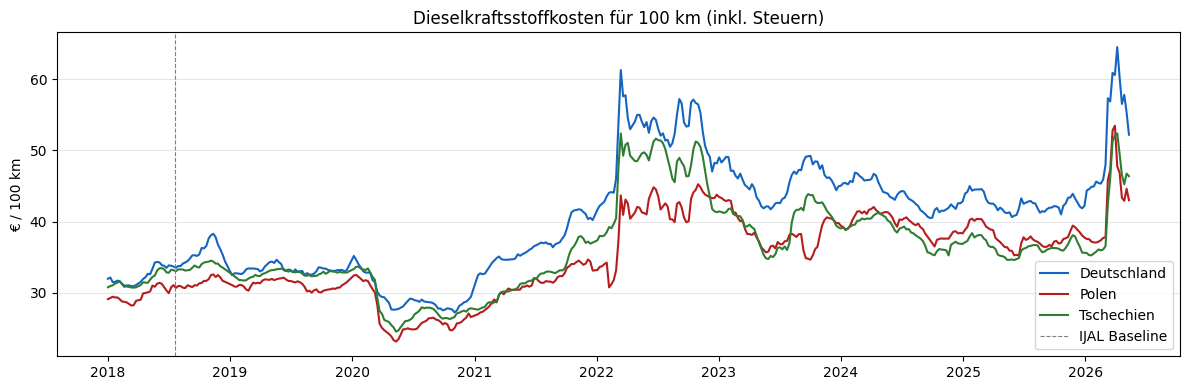

In [22]:
# Zeitreihe der Kraftstoffkosten (2018 bis heute)
fuel_plot = df_fuel["2018":] * FUEL_CONSUMPTION_L_PER_100KM

fig, ax = plt.subplots(figsize=(12, 4))
for country, color in zip(COUNTRIES, ["#1565C0", "#B71C1C", "#2E7D32"]):
    ax.plot(fuel_plot.index, fuel_plot[country], label=COUNTRY_LABELS[country], color=color)
ax.axvline(pd.Timestamp("2018-07-20"), color="gray", linestyle="--", linewidth=0.8, label="IJAL Baseline")
ax.set_ylabel("€ / 100 km")
ax.set_title("Dieselkraftsstoffkosten für 100 km (inkl. Steuern)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Fahrerkosten — Eurostat Structure of Earnings Survey (SES)

Statt Mindestlöhnen werden hier die tatsächlichen mittleren Bruttostundenlöhne aus der [Eurostat Structure of Earnings Survey](https://ec.europa.eu/eurostat/web/labour-market/earnings/database) genutzt. Die SES wird alle 4 Jahre erhoben; die aktuellsten verfügbaren Referenzjahre sind **2018** und **2022**.

Dataset: `EARN_SES18_RHR` / `EARN_SES22_RHR` (Mean hourly earnings by NUTS 1 region, alle Sektoren B–S exkl. Öffentlicher Dienst)

- **Deutschland**: Mittelwert der 6 ostdeutschen NUTS-1-Regionen (DE3 Berlin, DE4 Brandenburg, DE8 Mecklenburg-Vorpommern, DED Sachsen, DEE Sachsen-Anhalt, DEG Thüringen)
- **Polen**: Mittelwert der 7 NUTS-1-Makroregionen (kein nationales Aggregat im Datensatz)
- **Tschechien**: Nationaler Wert (CZ)

> Einschränkung: Die SES erfasst alle Wirtschaftssektoren — eine Aufschlüsselung nach NACE H (Transport und Lagerei) ist auf regionaler Ebene nicht verfügbar.

In [23]:
import eurostat

EAST_DE  = ["DE3", "DE4", "DE8", "DED", "DEE", "DEG"]
PL_NUTS1 = ["PL2", "PL4", "PL5", "PL6", "PL7", "PL8", "PL9"]

def get_ses_wages(dataset_code, year_col):
    df = eurostat.get_data_df(dataset_code, flags=False)
    geo_col = [c for c in df.columns if "geo" in c.lower()][0]
    df = df[(df["sex"] == "T") & (df["unit"] == "EUR")].rename(columns={geo_col: "geo"})
    df["wage"] = pd.to_numeric(df[year_col], errors="coerce")
    geo_wage = df.set_index("geo")["wage"]
    return {
        "Germany": geo_wage[EAST_DE].mean(),
        "Poland":  geo_wage[PL_NUTS1].mean(),
        "Czechia": geo_wage["CZ"],
    }

ses_wages_2018 = get_ses_wages("EARN_SES18_RHR", "2018")
ses_wages_2022 = get_ses_wages("EARN_SES22_RHR", "2022")

driver_costs_2018    = {c: ses_wages_2018[c] * HOURS_PER_100KM for c in COUNTRIES}
driver_costs_current = {c: ses_wages_2022[c] * HOURS_PER_100KM for c in COUNTRIES}

print("Mittlerer Bruttostundenlohn (€/h) und Fahrerkosten (€/100km):")
print(f"{'Land':<15} {'SES 2018':>10} {'K 2018':>8} {'SES 2022':>10} {'K 2022':>8} {'Δ':>8}")
for c in COUNTRIES:
    w18, w22 = ses_wages_2018[c], ses_wages_2022[c]
    k18, k22 = driver_costs_2018[c], driver_costs_current[c]
    print(f"{COUNTRY_LABELS[c]:<15} {w18:>9.2f}€  {k18:>6.2f}€  {w22:>9.2f}€  {k22:>6.2f}€  {(k22-k18)/k18*100:>+7.1f}%")

Mittlerer Bruttostundenlohn (€/h) und Fahrerkosten (€/100km):
Land              SES 2018   K 2018   SES 2022   K 2022        Δ
Deutschland         16.77€   20.97€      19.63€   24.54€    +17.0%
Polen                6.12€    7.65€       8.39€   10.49€    +37.1%
Tschechien           7.12€    8.90€       9.54€   11.92€    +34.0%


## 3. Mautkosten 2025

| Land | Strecke | 2018 | 2025 | Änderung |
|------|---------|------|------|----------|
| **Deutschland** | Berlin–Hamburg (287 km) | 15,60 €/100km | ~35,00 €/100km | CO₂-Aufschlag ab Dez. 2023 ([toll-collect.de](https://www.toll-collect.de)) |
| **Polen** | Warschau–Krakau (360 km) | 6,27 €/100km | ~7,80 €/100km | e-TOLL-System ([etoll.gov.pl](https://etoll.gov.pl)) |
| **Tschechien** | Prag–Brünn (186 km) | 18,24 €/100km | ~20,43 €/100km | Neues elektronisches System ([mytocz.eu](https://mytocz.eu)) |

In [24]:
tolls_current = {"Germany": 35.00, "Poland": 7.80, "Czechia": 20.43}
tolls_2018    = {"Germany": 15.60, "Poland": 6.27, "Czechia": 18.24}

for c in COUNTRIES:
    chg = (tolls_current[c] - tolls_2018[c]) / tolls_2018[c] * 100
    print(f"{COUNTRY_LABELS[c]}: {tolls_2018[c]:.2f} → {tolls_current[c]:.2f} €/100km ({chg:+.1f}%)")

Deutschland: 15.60 → 35.00 €/100km (+124.4%)
Polen: 6.27 → 7.80 €/100km (+24.4%)
Tschechien: 18.24 → 20.43 €/100km (+12.0%)


## 4. Reifenkosten 2025

10 Reifen 295/60R22.5, Laufleistung 120.000 km. Preise moderat gestiegen (Inflation, Rohstoffkosten).

In [25]:
tyre_price_current = {"Germany": 710.0, "Poland": 720.0, "Czechia": 680.0}
tyre_price_2018    = {"Germany": 634.2, "Poland": 680.92, "Czechia": 621.0}

tyre_costs_current = {c: tyre_price_current[c] * TYRE_COUNT / TYRE_DURATION_KM * 100 for c in COUNTRIES}
tyre_costs_2018    = {c: tyre_price_2018[c]    * TYRE_COUNT / TYRE_DURATION_KM * 100 for c in COUNTRIES}

for c in COUNTRIES:
    chg = (tyre_costs_current[c] - tyre_costs_2018[c]) / tyre_costs_2018[c] * 100
    print(f"{COUNTRY_LABELS[c]}: {tyre_costs_2018[c]:.2f} → {tyre_costs_current[c]:.2f} €/100km ({chg:+.1f}%)")

Deutschland: 5.29 → 5.92 €/100km (+12.0%)
Polen: 5.67 → 6.00 €/100km (+5.7%)
Tschechien: 5.17 → 5.67 €/100km (+9.5%)


## 5. Gesamtvergleich 2018 vs. aktuell

In [26]:
categories = ["Kraftstoff", "Fahrer", "Maut", "Reifen"]
data_2018    = {"Kraftstoff": fuel_costs_2018,    "Fahrer": driver_costs_2018,
                "Maut": tolls_2018,                "Reifen": tyre_costs_2018}
data_current = {"Kraftstoff": fuel_costs_current, "Fahrer": driver_costs_current,
                "Maut": tolls_current,             "Reifen": tyre_costs_current}

year = current_date[:4]
print(f"{'Kostenposition':<14}  {'DE 2018':>8} {'DE '+year:>8}  {'PL 2018':>8} {'PL '+year:>8}  {'CZ 2018':>8} {'CZ '+year:>8}")
print("-" * 82)
for cat in categories:
    row = f"{cat:<14}  "
    for c in COUNTRIES:
        row += f"  {data_2018[cat][c]:>7.2f}  {data_current[cat][c]:>7.2f}"
    print(row)
print("-" * 82)
row = f"{'TOTAL':<14}  "
for c in COUNTRIES:
    t18  = sum(data_2018[cat][c]    for cat in categories)
    tnow = sum(data_current[cat][c] for cat in categories)
    row += f"  {t18:>7.2f}  {tnow:>7.2f}"
print(row)
print("\nAlle Werte in €/100km")
print(f"Fahrerkosten: SES 2018 vs. SES 2022 (aktuellste verfügbare SES-Runde)")

Kostenposition   DE 2018  DE 2026   PL 2018  PL 2026   CZ 2018  CZ 2026
----------------------------------------------------------------------------------
Kraftstoff          33.71    52.20    31.10    43.02    33.19    46.39
Fahrer              20.97    24.54     7.65    10.49     8.90    11.92
Maut                15.60    35.00     6.27     7.80    18.24    20.43
Reifen               5.29     5.92     5.67     6.00     5.17     5.67
----------------------------------------------------------------------------------
TOTAL               75.56   117.66    50.69    67.30    65.51    84.41

Alle Werte in €/100km
Fahrerkosten: SES 2018 vs. SES 2022 (aktuellste verfügbare SES-Runde)


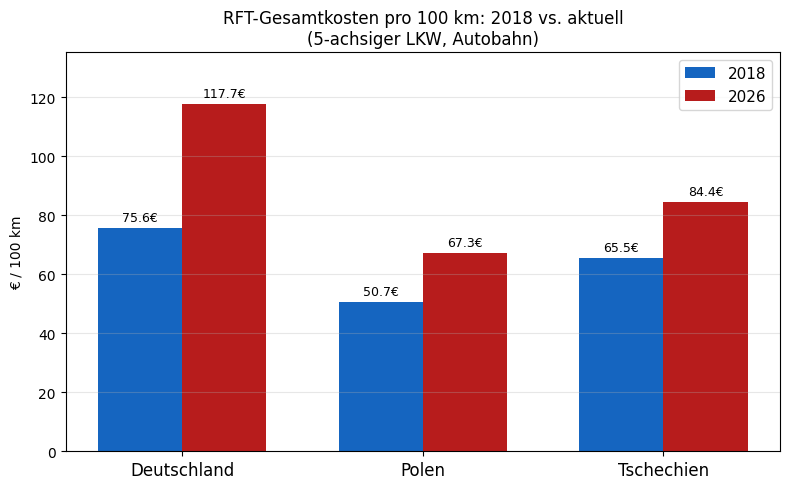

In [27]:
import numpy as np

x = np.arange(len(COUNTRIES))
width = 0.35

totals_2018    = [sum(data_2018[cat][c]    for cat in categories) for c in COUNTRIES]
totals_current = [sum(data_current[cat][c] for cat in categories) for c in COUNTRIES]

fig, ax = plt.subplots(figsize=(8, 5))
bars18  = ax.bar(x - width/2, totals_2018,    width, label="2018",  color="#1565C0")
bars22  = ax.bar(x + width/2, totals_current, width, label=year,    color="#B71C1C")

ax.bar_label(bars18,  fmt="%.1f€", padding=3, fontsize=9)
ax.bar_label(bars22,  fmt="%.1f€", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([COUNTRY_LABELS[c] for c in COUNTRIES], fontsize=12)
ax.set_ylabel("€ / 100 km")
ax.set_title("RFT-Gesamtkosten pro 100 km: 2018 vs. aktuell\n(5-achsiger LKW, Autobahn)")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(totals_current) * 1.15)

plt.tight_layout()
plt.savefig("ijal_cost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Interpretation

1. **Deutschland (Ostdeutschland)**: Der CO₂-Aufschlag auf die LKW-Maut (ab Dez. 2023) hat die Mautkosten mehr als verdoppelt und ist damit der dominierende Kostentreiber seit 2018. Die Löhne in Ostdeutschland lagen bereits 2018 deutlich über dem nationalen Mindestlohn.

2. **Polen**: Trotz stark gestiegener Löhne (+37% SES 2018→2022) bleibt Polen durch niedrige Kraftstoffpreise und geringe Maut der kostengünstigste Standort.

3. **Tschechien**: Entwicklung zwischen DE und PL — Löhne stiegen um +34%, kein vergleichbarer Mautsprung.

### Datenquellen und Einschränkungen

| Kostenposition | Quelle | Aktualisierung |
|---|---|---|
| Kraftstoff | EU Weekly Oil Bulletin | wöchentlich |
| Fahrerkosten | Eurostat SES (EARN_SES_RHR) | alle 4 Jahre (aktuell: 2022) |
| Maut | Toll Collect / e-TOLL / MyTocz | manuell recherchiert |
| Reifen | Händlerpreise (Schätzung) | manuell |

- SES = alle Sektoren B–S, keine NACE H (Transport)-Aufschlüsselung auf regionaler Ebene
- Bruttolohn ≠ Arbeitgebergesamtkosten (Sozialabgaben nicht enthalten)
- Mautkosten basieren auf einer Referenzstrecke je Land
- Wechselkursschwankungen (PLN, CZK) beeinflussen die €-Vergleichswerte für Polen